<a href="https://colab.research.google.com/github/hafizurrahman1014-sys/Machine-Learning-projects/blob/main/Copy_of_K_means_Clustering(2131012).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# K-Means and Scaling
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# To display plots inside Colab
%matplotlib inline

In [ ]:
# Load the dataset

df = pd.read_csv('insurance.csv')

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Display dataset shape and columns

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

Dataset Shape: (1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [ ]:
# Selecting only Age and BMI for clustering

X = df[['age', 'bmi']]

# Display first 5 rows of selected features
X.head()

,age,bmi
0,19,27.900
1,18,33.770
2,28,33.000
3,33,22.705
4,32,28.880


In [ ]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# View first 5 scaled rows
X_scaled[:5]

array([[-1.43876426, -0.45332   ],
       [-1.50996545,  0.5096211 ],
       [-0.79795355,  0.38330685],
       [-0.4419476 , -1.30553108],
       [-0.51314879, -0.29255641]])

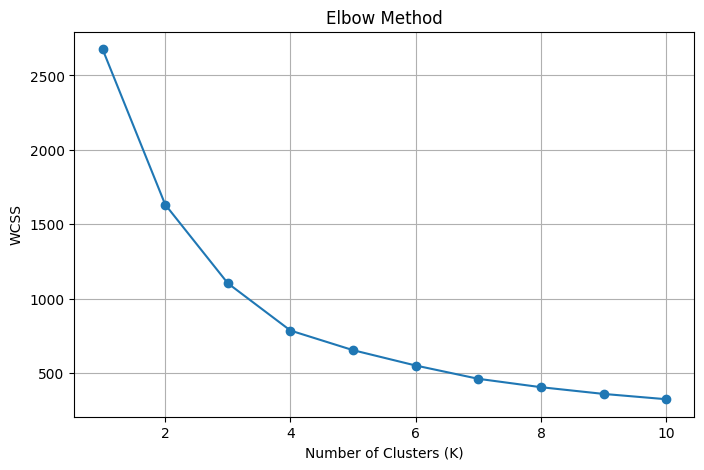

In [ ]:
# Finding optimal K using Elbow Method

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.grid(True)
plt.show()

In [ ]:
# Create K-Means model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train model
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
# Assign cluster labels to each record

df['Cluster'] = kmeans.labels_

# Display first 5 rows

df.head()

,age,sex,bmi,children,smoker,region,charges,Cluster
0,19,female,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [ ]:
# Number of samples in each cluster

print(df['Cluster'].value_counts())

Cluster
0    530
2    443
1    365
Name: count, dtype: int64


In [ ]:
# New person data

new_person = [[30, 28]]

# Scale using same scaler

new_person_scaled = scaler.transform(new_person)

# Predict cluster

predicted_cluster = kmeans.predict(new_person_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


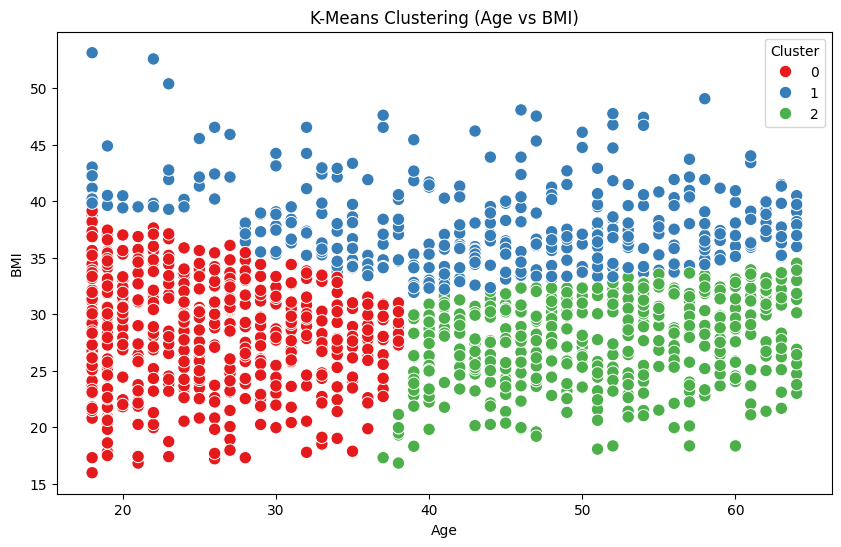

In [ ]:
# Scatter plot of clusters

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['age'],
    y=df['bmi'],
    hue=df['Cluster'],
    palette='Set1',
    s=80
)

plt.title('K-Means Clustering (Age vs BMI)')
plt.xlabel('Age')
plt.ylabel('BMI')

plt.show()

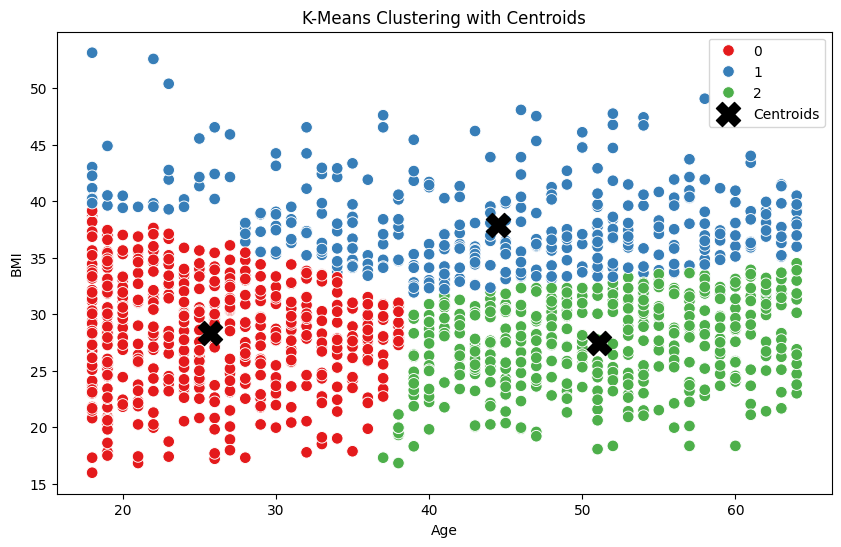

In [ ]:
# Get centroids back to original scale

centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

# Plot clusters

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['age'],
    y=df['bmi'],
    hue=df['Cluster'],
    palette='Set1',
    s=70
)

# Plot centroids

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='black',
    marker='X',
    s=300,
    label='Centroids'
)

plt.title('K-Means Clustering with Centroids')
plt.xlabel('Age')
plt.ylabel('BMI')

plt.legend()
plt.show()

In [ ]:
# Display centroid coordinates

centroid_df = pd.DataFrame(
    centroids,
    columns=['Age_Centroid', 'BMI_Centroid']
)

centroid_df

,Age_Centroid,BMI_Centroid
0,25.666038,28.329443
1,44.474114,37.875845
2,51.097506,27.466179
